# Linear Regression using Gradient Descent

This notebook implements Linear Regression from scratch using Gradient Descent.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Load and Understand the Data

X represents the house area in square meters (m²).

y represents the house price in thousands.

In [2]:
X = np.array([50, 60, 70, 80, 90])
y = np.array([150, 180, 210, 240, 270])

print("X:", X)
print("y:", y)

X: [50 60 70 80 90]
y: [150 180 210 240 270]


## 2. Linear Regression using Gradient Descent

In [3]:
class LinearRegressionGD:
    
    def __init__(self, learning_rate=0.001, n_iters=100):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.theta_0 = 0
        self.theta_1 = 0
        self.sse_history = []

    def fit(self, X, y):
        n = len(X)

        for i in range(self.n_iters):
            y_pred = self.theta_0 + self.theta_1 * X
            error = y_pred - y

            sse = np.sum(error ** 2)
            self.sse_history.append(sse)

            d_theta_0 = (2 / n) * np.sum(error)
            d_theta_1 = (2 / n) * np.sum(error * X)

            self.theta_0 -= self.learning_rate * d_theta_0
            self.theta_1 -= self.learning_rate * d_theta_1

        return self

    def predict(self, X):
        return self.theta_0 + self.theta_1 * X

    def plot_training(self, X, y):
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        # SSE over iterations
        axes[0].plot(self.sse_history)
        axes[0].set_title("SSE over Iterations")
        axes[0].set_xlabel("Iterations")
        axes[0].set_ylabel("SSE")

        # Regression line
        axes[1].scatter(X, y)
        axes[1].plot(X, self.predict(X))
        axes[1].set_title("Linear Regression")
        axes[1].set_xlabel("House Size (m²)")
        axes[1].set_ylabel("Price (thousands)")

        plt.show()

## 3. Create and Train the Model

Learning rate = 0.001

Number of iterations = 100

In [4]:
model = LinearRegressionGD(learning_rate=0.001, n_iters=100)

model.fit(X, y)

print("Theta 0:", model.theta_0)
print("Theta 1:", model.theta_1)

Theta 0: -1.0055957901462392e+95
Theta 1: -7.326427288635144e+96


## 4. Prediction

Predict the price of a house with an area of 70 m².

In [5]:
predicted_price = model.predict(70)

print("Predicted price for 70 m²:", predicted_price, "thousand")

Predicted price for 70 m²: -5.129504697834747e+98 thousand


## 5. Visualization

### SSE and Regression Line

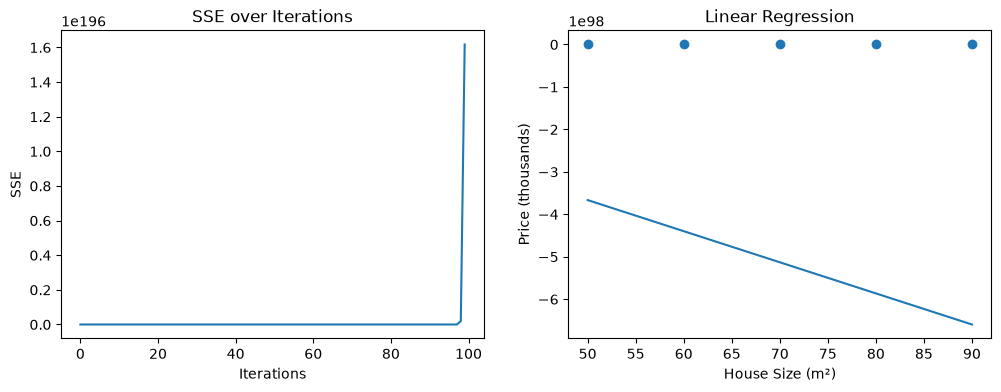

In [6]:
model.plot_training(X, y)

## 6. Experiment with Different Learning Rates

We compare a very large learning rate with a very small learning rate.

In [7]:
large_lr_model = LinearRegressionGD(learning_rate=0.01, n_iters=100)

large_lr_model.fit(X, y)

print("Large Learning Rate")
print("Theta 0:", large_lr_model.theta_0)
print("Theta 1:", large_lr_model.theta_1)
print("Final SSE:", large_lr_model.sse_history[-1])

Large Learning Rate
Theta 0: -1.1349322671141837e+199
Theta 1: -8.268728662168217e+200
Final SSE: inf


C:\Users\XPS STORE\AppData\Local\Temp\ipykernel_12716\419542184.py:17: RuntimeWarning: overflow encountered in square
  sse = np.sum(error ** 2)


In [8]:
small_lr_model = LinearRegressionGD(learning_rate=0.0001, n_iters=100)

small_lr_model.fit(X, y)

print("Small Learning Rate")
print("Theta 0:", small_lr_model.theta_0)
print("Theta 1:", small_lr_model.theta_1)
print("Final SSE:", small_lr_model.sse_history[-1])

Small Learning Rate
Theta 0: 0.04113676040970018
Theta 1: 2.999435373457505
Final SSE: 0.00033181560776546876


## 7. Learning Rate Comparison

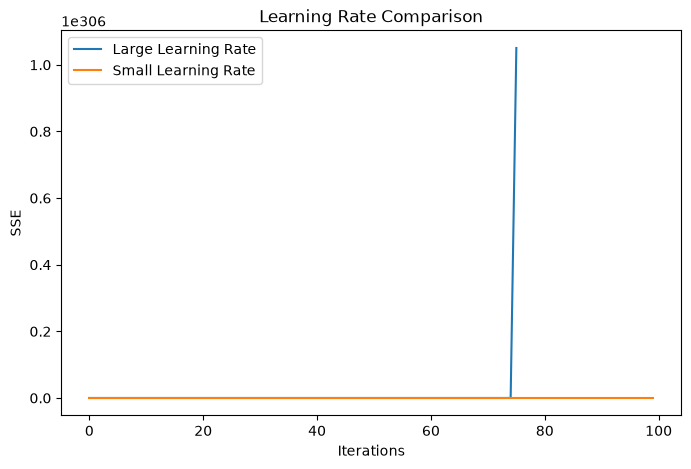

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(
    large_lr_model.sse_history,
    label="Large Learning Rate"
)

plt.plot(
    small_lr_model.sse_history,
    label="Small Learning Rate"
)

plt.xlabel("Iterations")
plt.ylabel("SSE")
plt.title("Learning Rate Comparison")
plt.legend()
plt.show()

## 8. Conclusion

Linear Regression was implemented from scratch using Gradient Descent.

The model learned the parameters theta_0 and theta_1 by repeatedly updating them to reduce the Sum of Squared Errors (SSE).

A learning rate that is too large can make the training unstable, while a learning rate that is too small can make convergence very slow.